# Módulo 2 — Estimación de densidad

**Objetivo:** entender qué pasa cuando **no hay** variable de salida $y$ — solo
queremos modelar qué tan densos/probables son los datos mismos. Es el caso no
supervisado: `KDMProjLayer` en vez de `KDMLayer` (sin lado "y"), y una conexión
sorprendente: con kernel RBF, esto **es literalmente una Mezcla Gaussiana** (GMM).

**Requisito:** Módulos 0 y 1 (reusamos la Ec. 3/4 y la idea de `c_x`/`c_w` como
parámetros aprendidos).

**Fuente matemática:** paper, §3.3 (estimación de densidad, Ec. 7).
**Fuente de código:** `external/kdm/kdm/layers/kdm_proj_layer.py`,
`external/kdm/kdm/models/kdm_den_est_model.py`.

## 1. Estimación no paramétrica vs. paramétrica (§3.3)

Recordando el Módulo 0: una KDM $\rho_x = (D, p=(1/\ell,\ldots,1/\ell), k_{\mathrm{rbf},\sigma})$
construida directamente de un conjunto de muestras $D$ (vía `samples2dm`) **ya es**
un estimador de densidad — el Teorema de Parzen garantiza que converge a la
densidad real. Eso es estimación **no paramétrica**: los propios datos son los
parámetros, sin optimización.

El paper también permite estimación **paramétrica**: en vez de usar TODOS los
datos como componentes, se aprende una KDM con $K \ll \ell$ componentes
$(C, p, \theta)$ maximizando la verosimilitud de los datos de entrenamiento:

$$\max_{C,\,p,\,\theta} \ \sum_{i=1}^{\ell} \log \hat{f}_\rho(x_i) \tag{Eq. 7}$$

Esto es exactamente lo que hace `KDMDenEstModel`: aprende $C$ (=`c_x`) y $p$ (=`c_w`)
por descenso de gradiente — mucho más compacto que guardar todo el dataset, y no
requiere reevaluar contra $\ell$ puntos en cada predicción.

## 2. `KDMProjLayer`: la función de proyección sin lado "y"

```python
# external/kdm/kdm/layers/kdm_proj_layer.py:26-52
def __init__(self, kernel, dim_x, x_train=True, w_train=True, n_comp=0):
    c_x = torch.randn(n_comp, dim_x) * 0.05
    c_w = torch.full((n_comp,), 1.0 / n_comp)
    self.c_x = nn.Parameter(c_x, requires_grad=x_train)
    self.c_w = nn.Parameter(c_w, requires_grad=w_train)

def forward(self, inputs):                          # inputs: (bs, dim_x) -- NO es una KDM, es un punto crudo
    comp_w = self.c_w.abs() + self.eps
    comp_w = comp_w / comp_w.sum()                   # p_i normalizados
    in_v = inputs.unsqueeze(1)
    out_vw = self.kernel(in_v, self.c_x) ** 2         # k(x, c_x^(i))^2
    return torch.einsum('...j,...ij->...', comp_w, out_vw)   # Ec. 3: sum_i p_i k^2(x, x^(i))
```

Comparado con `KDMLayer` (Módulo 1): no hay `c_y`, no hay Ec. 12 — solo la
función de proyección $f_\rho(x)$ (Ec. 3) evaluada directo. Nótese también que
`inputs` entra como un tensor crudo `(bs, dim_x)`, no como una KDM `(bs,n,d+1)` —
aquí no hace falta representar incertidumbre en la entrada.

## 3. `KDMDenEstModel`: por qué es (literalmente) una Mezcla Gaussiana

```python
# external/kdm/kdm/models/kdm_den_est_model.py
def forward(self, x):
    return torch.log(self.kdmproj(x) + self.eps) + self.kernel.log_weight()
    #      log( f_rho(x) )                       + log(M_k)   =  log( f_hat_rho(x) )   -- Ec. 4 en escala log

def get_distrib(self):
    scale = self.kernel.sigma.detach() / math.sqrt(2.0)
    return MixtureSameFamily(
        mixture_distribution=Categorical(probs=comp_w),          # pesos = c_w
        component_distribution=Independent(Normal(loc=self.kdmproj.c_x, scale=scale), 1),
    )
```

Con el kernel RBF, $k(x,y)^2 = \exp(-\|x-y\|^2/\sigma^2)$ — que es proporcional a
una densidad Normal con **desviación estándar $\sigma/\sqrt{2}$**. Por eso
`get_distrib()` arma una `MixtureSameFamily` de Gaussianas centradas en `c_x`,
con pesos `c_w`: **entrenar una `KDMDenEstModel` con kernel RBF es, matemáticamente,
entrenar un GMM** por descenso de gradiente en vez de EM — con la ventaja de que
escala mejor a mini-batches (el paper lo discute explícitamente en §3.5).

**Precaución del paper (nota al pie de la Ec. 7):** maximizar la verosimilitud
puede estar mal condicionado — si $\sigma \to 0$ y un componente coincide con una
muestra, la verosimilitud crece sin límite (una Gaussiana degenerada). El código
se protege de esto **estructuralmente**: `RBFKernelLayer.sigma` se parametriza
como `softplus(raw) + min_sigma` (Módulo 1, §4) — `sigma` nunca puede bajar de
`min_sigma`, sin necesidad de recortar manualmente durante el entrenamiento.

## 4. Ejercicio práctico: densidad de dígitos MNIST en 2D

Para poder **ver** la densidad estimada, reducimos las imágenes a 2D con PCA
(determinístico, sin entrenar nada) y ajustamos una `KDMDenEstModel` por separado
para dos clases de dígitos distintas.

In [1]:
import numpy as np
import torch
import torchvision
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

from kdm.models import KDMDenEstModel
from kdm.init import init_kdm_proj_layer

torch.manual_seed(42)
np.random.seed(42)

mnist_train = torchvision.datasets.MNIST(root="../../../data/mnist", train=True, download=False)

N_PER_CLASS = 500
DIGIT_A, DIGIT_B = 0, 1   # dos clases bien distintas para que la separacion sea visible

def digit_subset(digit, n):
    mask = (mnist_train.targets == digit)
    imgs = mnist_train.data[mask][:n].float().reshape(n, -1) / 255.0
    return imgs

X_a = digit_subset(DIGIT_A, N_PER_CLASS)
X_b = digit_subset(DIGIT_B, N_PER_CLASS)

# PCA a 2D ajustado sobre AMBAS clases juntas, para que compartan el mismo plano
pca = PCA(n_components=2, random_state=42)
pca.fit(torch.cat([X_a, X_b]).numpy())

Z_a = torch.tensor(pca.transform(X_a.numpy()), dtype=torch.float32)
Z_b = torch.tensor(pca.transform(X_b.numpy()), dtype=torch.float32)

print(f"digito {DIGIT_A}: {Z_a.shape}   digito {DIGIT_B}: {Z_b.shape}")
print("varianza explicada por las 2 componentes:", pca.explained_variance_ratio_.sum().round(3))

digito 0: torch.Size([500, 2])   digito 1: torch.Size([500, 2])
varianza explicada por las 2 componentes: 0.427


In [2]:
def fit_density_model(Z, n_comp=30, epochs=200, lr=0.05):
    model = KDMDenEstModel(dim_x=2, sigma=1.0, n_comp=n_comp, trainable_sigma=True)

    idx_init = torch.randperm(Z.shape[0])[:n_comp]
    init_kdm_proj_layer(model.kdmproj, Z[idx_init], init_sigma=True)

    opt = torch.optim.Adam(model.parameters(), lr=lr)
    for epoch in range(epochs):
        opt.zero_grad()
        loss = -model(Z).mean()          # Ec. 7: maximizar log-verosimilitud = minimizar su negativo
        loss.backward()
        opt.step()
    return model, loss.item()

model_a, loss_a = fit_density_model(Z_a)
model_b, loss_b = fit_density_model(Z_b)

print(f"digito {DIGIT_A}: log-verosimilitud media final = {-loss_a:.3f}, sigma = {model_a.kernel.sigma.item():.3f}")
print(f"digito {DIGIT_B}: log-verosimilitud media final = {-loss_b:.3f}, sigma = {model_b.kernel.sigma.item():.3f}")

digito 0: log-verosimilitud media final = -4.261, sigma = 0.985
digito 1: log-verosimilitud media final = -1.529, sigma = 0.187


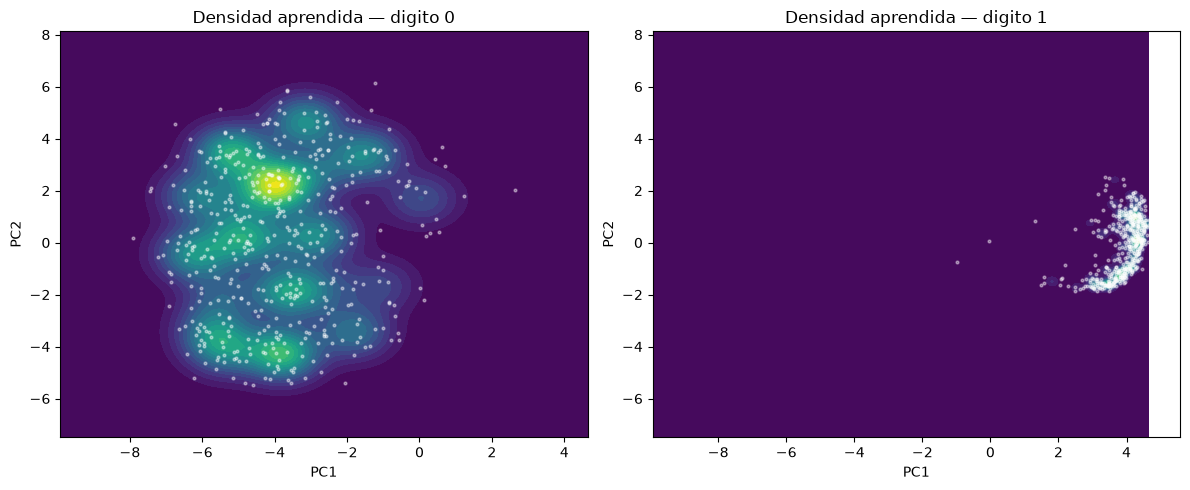

Figura guardada en learning/kdm/notebooks/densidad_digitos.png


In [3]:
# --- Visualizar la densidad aprendida (via get_distrib) como mapa de calor + los puntos reales ---
xs = torch.linspace(Z_a[:,0].min().item()-2, Z_a[:,0].max().item()+2, 150)
ys = torch.linspace(Z_a[:,1].min().item()-2, Z_a[:,1].max().item()+2, 150)
grid_x, grid_y = torch.meshgrid(xs, ys, indexing="ij")
grid = torch.stack([grid_x.flatten(), grid_y.flatten()], dim=1)

with torch.no_grad():
    dens_a = model_a.get_distrib().log_prob(grid).exp().reshape(150, 150)
    dens_b = model_b.get_distrib().log_prob(grid).exp().reshape(150, 150)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, dens, Z, digit in zip(axes, [dens_a, dens_b], [Z_a, Z_b], [DIGIT_A, DIGIT_B]):
    ax.contourf(grid_x, grid_y, dens, levels=20, cmap="viridis")
    ax.scatter(Z[:,0], Z[:,1], s=4, c="white", alpha=0.4)
    ax.set_title(f"Densidad aprendida — digito {digit}")
    ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
plt.tight_layout()
plt.savefig("densidad_digitos.png", dpi=100)
plt.show()
print("Figura guardada en learning/kdm/notebooks/densidad_digitos.png")

El mapa de calor debe concentrarse donde están los puntos blancos (los datos reales) de cada dígito — la KDM aprendió, con solo 30 componentes, una superficie de densidad razonable a partir de 500 muestras.

In [4]:
# --- Preview de OOD (se profundiza en el Modulo 6): el modelo de una clase
# debe asignar MENOS densidad a muestras de la OTRA clase ---
with torch.no_grad():
    log_dens_a_on_a = model_a(Z_a).mean().item()
    log_dens_a_on_b = model_a(Z_b).mean().item()

print(f"modelo del digito {DIGIT_A}, evaluado en datos del digito {DIGIT_A} (propios): {log_dens_a_on_a:.3f}")
print(f"modelo del digito {DIGIT_A}, evaluado en datos del digito {DIGIT_B} (ajenos):  {log_dens_a_on_b:.3f}")
assert log_dens_a_on_a > log_dens_a_on_b, "la densidad dentro de clase deberia ser mayor que fuera de clase"
print("\nOK: el modelo asigna mayor verosimilitud a datos de su propia clase.")

modelo del digito 0, evaluado en datos del digito 0 (propios): -4.261
modelo del digito 0, evaluado en datos del digito 1 (ajenos):  -14.057

OK: el modelo asigna mayor verosimilitud a datos de su propia clase.


## Resumen y próximo módulo

- `KDMProjLayer` implementa la función de proyección $f_\rho(x)$ (Ec. 3) sin lado
  $y$ — solo `c_x`/`c_w`, sin `c_y`.
- `KDMDenEstModel.forward` = $\log \hat{f}_\rho(x)$ (Ec. 4 en escala log);
  entrenar por descenso de gradiente maximiza la Ec. 7 (MLE).
- Con kernel RBF, una KDM de densidad **es** una Mezcla Gaussiana — `get_distrib()`
  lo hace explícito devolviendo un objeto `MixtureSameFamily` de PyTorch.
- `min_sigma` (Módulo 1, RBFKernelLayer) evita el mal condicionamiento de la Ec. 7
  que el paper advierte en su nota al pie, sin necesidad de recortar manualmente.
- Ya vimos un primer indicio de que la densidad estimada separa clases (más
  densidad dentro de la propia clase que fuera) — la base de la detección de
  anomalías/OOD del Módulo 6.

**Módulo 3** (`03_densidades_conjuntas.ipynb`, pendiente): cómo modelar la
densidad conjunta $(X, Y)$ combinando dos kernels distintos con
`CrossProductKernelLayer` — el mecanismo que prefigura directamente la
comparación KDM-vs-NPC de la tesis (densidad conjunta atributos+clase).